# NLP 新闻分析与真假分类：学习笔记

按顺序运行：**依赖与参数 → 读取 → POS/NER → 清洗与 N-gram → 情绪 → 主题 → 分类器**。
首次打开或修改依赖配置后，请重启内核并运行全部。主题数比较包含 20 个模型，耗时最长。

| 章节 | 输入 | 主要输出与用途 |
|---|---|---|
| 1～8 数据准备 | fake_news_data.csv | news_data：原始新闻；标签数量图 |
| 9～15 POS / NER | 原始正文 | token_details、entity_details：带新闻索引的明细与排行 |
| 16～17 清洗 / N-gram | 原始正文副本 | processed_news：每篇新闻独立的词列表和元组列表 |
| 18～20 情绪分析 | 原始正文 | sentiment_results：VADER 分数；情绪分布图 |
| 21～26 主题分析 | 还原后的词列表 | LDA / LSI 候选模型、评分、关键词及代表新闻 |
| 27～32 监督分类 | 原始正文与真假标签 | news_classifier、predict_news：分类与预测 |

## 阅读与维护约定

- 第 2 节集中存放可调参数；函数放在首次使用的位置，先看说明，再看调用。
- 标题只用于展示和追溯；原始 CSV 不回写，分析列写入副本。
- POS、NER、VADER 使用原始正文；主题模型使用清洗词列表。
- 分类器独立划分训练集后学习 TF-IDF，不使用全量主题结果，避免测试信息泄漏。
- 排行通常统计出现次数，情绪统计新闻篇数；具体分母在各节说明。
- 保留中文教学注释，图表使用英文标签以兼容当前字体。

## 1. 导入依赖库

标准库、数据处理、NLP 与分类依赖统一列出。Windows MKL 配置必须在第三方库导入之前执行。

In [1]:
# 标准库：路径、源文件校验、标点判断和运行环境。
from pathlib import Path
import hashlib
import os
import string
import unicodedata

# 当前 Windows 环境采用 MKL 单线程后端，避免多份 OpenMP 运行库冲突。
# 改动此设置后需重启内核，不能依靠重新运行 import 卸载已加载的库。
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"

# 先加载 spaCy，再加载数值库；保留已验证的环境加载顺序。
import spacy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

# NLP：NLTK 提供停用词与 N-gram，VADER 提供情绪规则，gensim 提供主题模型。
from nltk.corpus import stopwords
from nltk import ngrams
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, LsiModel, TfidfModel, CoherenceModel

# 监督学习：Pipeline 保证训练集独立学习词典和 IDF。
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 2. 集中配置参数

这里控制数据路径、展示条数、情绪阈值、主题范围和分类划分。下文保留原变量名，修改参数后从头运行，避免新旧结果混用。

In [2]:
# 数据与展示
DATA_PATH = Path("fake_news_data.csv")
LABEL_COLUMN = "fake_or_factual"
TEXT_COLUMN = "text"
PREVIEW_ROWS = 5
NEWS_GROUPS = ["Factual News", "Fake News"]
label_colors = {
    "Factual News": "#3B6EA8",  # 真实新闻：蓝色
    "Fake News": "#C47A2C",     # 假新闻：橙色
}
TOP_N = 20
NER_PLOT_TOP_N = 15
NGRAM_TOP_N = 15  # 调整排行榜和图表的展示条数。

# NLP 与情绪
MODEL_NAME = "en_core_web_sm"
POSITIVE_THRESHOLD = 0.05
NEGATIVE_THRESHOLD = -0.05
SENTIMENT_ORDER = ["正面", "负面", "中性（正常）"]

# 主题模型
TOPIC_COUNTS = list(range(2, 12))
TOPIC_SEED = 42
TOPIC_WORDS = 10
LDA_PASSES = 10
VIEW_TOPIC_COUNT = 8

# 分类器
CLASSIFIER_SEED = 42
TEST_SIZE = 0.2
CLASS_LABELS = ["Fake News", "Factual News"]

# 分类特征参数只由训练集拟合；固定值与原实现一致。
CLASSIFIER_TFIDF = dict(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
CLASSIFIER_MAX_ITER = 1000
CLASSIFIER_C = 1.0

In [3]:
def display_full_table(table):
    """临时显示完整文字；退出后恢复 pandas 设置，不影响后面的预览。"""
    with pd.option_context("display.max_colwidth", None):
        display(table)


## 3. 读取新闻数据

`pd.read_csv()` 将 CSV 读取为 DataFrame。这里只读取文件，不会向源 CSV 写入任何内容。

In [4]:
# 读取前先记录源文件的 SHA-256，便于最后检查文件是否保持不变。
source_hash_before = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

# 读取 CSV；每一行代表一条新闻。
news_data = pd.read_csv(DATA_PATH)
# 一次保存原始快照，后续检查直接比较内存，避免反复读盘。
news_data_snapshot = news_data.copy(deep=True)

print(f"数据行数：{news_data.shape[0]:,}")
print(f"数据列数：{news_data.shape[1]}")
print(f"字段名：{news_data.columns.tolist()}")

数据行数：198
数据列数：4
字段名：['title', 'text', 'date', 'fake_or_factual']


## 4. 预览前 5 条新闻

使用 `head()` 快速确认标题、正文、日期和真假标签是否正确读取。

In [5]:
# DataFrame 放在代码单元格最后一行，Jupyter 会自动以表格形式展示。
news_data.head(PREVIEW_ROWS)

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


## 5. 检查真假新闻字段

在统计之前，先确认 `fake_or_factual` 字段存在、没有缺失值，并且只包含两种标签。这能避免错误字段或空标签导致的统计偏差。

In [6]:
# 字段不存在时立即报出易于理解的错误。
assert LABEL_COLUMN in news_data.columns, f"缺少标签字段：{LABEL_COLUMN}"

# 本数据集的每条新闻都应有真假标签。
missing_label_count = news_data[LABEL_COLUMN].isna().sum()
assert missing_label_count == 0, f"发现 {missing_label_count} 条新闻缺少真假标签"

# drop_duplicates() 只用于查看有哪些标签，不会删除原 DataFrame 中的新闻。
label_values = news_data[LABEL_COLUMN].drop_duplicates().tolist()
assert len(label_values) == 2, f"期望 2 种真假标签，实际得到：{label_values}"

print("真假标签：", label_values)
print("标签缺失数：", missing_label_count)

真假标签： ['Fake News', 'Factual News']
标签缺失数： 0


## 6. 统计真假新闻数量

`value_counts()` 统计每个标签的出现次数。在数量之外，同时计算占比，便于判断两类样本是否平衡。

In [7]:
# sort=False 保留标签在原数据中首次出现的顺序。
news_label_statistics = (
    news_data[LABEL_COLUMN]
    .value_counts(sort=False)
    .rename_axis("News Type")
    .reset_index(name="Count")
)

# 占比 = 当前类别数量 / 全部新闻数量 × 100%。
news_label_statistics["Share (%)"] = (
    news_label_statistics["Count"] / len(news_data) * 100
).round(2)

# 为了让表格和图表都更容易比较，按数量从高到低排序。
news_label_statistics = (
    news_label_statistics
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

news_label_statistics

,News Type,Count,Share (%)
0,Factual News,100,50.51
1,Fake News,98,49.49


## 7. 可视化真假新闻数量

因为只有两个离散类别，柱状图最适合直接对比数量。纵轴从 0 开始，柱子上方标出具体数值。

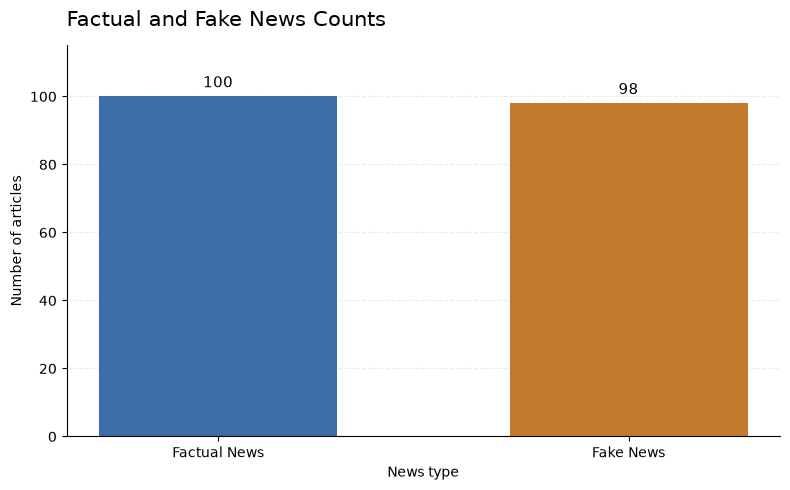

In [8]:
# 使用固定颜色，避免每次运行时图表配色变化。
bar_colors = [
    label_colors.get(news_type, "#7A7A7A")
    for news_type in news_label_statistics["News Type"]
]

figure, axis = plt.subplots(figsize=(8, 5))
bars = axis.bar(
    news_label_statistics["News Type"],
    news_label_statistics["Count"],
    color=bar_colors,
    width=0.58,
)

# 图表文字使用英文，避免当前 Matplotlib 默认字体缺少中文字形而出现方框。
axis.set_title("Factual and Fake News Counts", loc="left", fontsize=15, pad=14)
axis.set_xlabel("News type")
axis.set_ylabel("Number of articles")
axis.set_ylim(0, news_label_statistics["Count"].max() * 1.15)
axis.grid(axis="y", linestyle="--", alpha=0.25)
axis.set_axisbelow(True)
axis.spines[["top", "right"]].set_visible(False)

# 直接在柱子上标注数量，无需通过坐标轴估算。
axis.bar_label(bars, padding=4, fontsize=11)

plt.tight_layout()
plt.show()

## 8. 结果检查

确认统计表的总数与 CSV 总行数一致，占比约等于 100%，并确认分析前后的 CSV 文件哈希没有变化。

In [9]:
# 各类别数量之和必须等于新闻总数。
assert news_label_statistics["Count"].sum() == len(news_data)

# 占比保留两位小数，因此允许很小的四舍五入误差。
assert abs(news_label_statistics["Share (%)"].sum() - 100) < 0.1

# 读取和分析过程不应修改源 CSV 文件。
source_hash_after = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert source_hash_after == source_hash_before

print(f"✓ 已成功读取 {len(news_data):,} 条新闻。")
print("✓ 真假新闻统计总数与数据行数一致。")
print("✓ fake_news_data.csv 未被修改。")

✓ 已成功读取 198 条新闻。
✓ 真假新闻统计总数与数据行数一致。
✓ fake_news_data.csv 未被修改。


## 从数据准备进入正文分析

下方依次查看原文语言特征、清洗结果、情绪、主题和分类。每张统计表保留自己的计数口径。

## 9. 使用 spaCy 分析新闻正文

本次输入为 `text` 正文，保留原始大小写、标点和上下文，让模型完成分词、POS tagging 和 NER。

每条新闻独立处理，`news_docs` 与 `news_data` 的行顺序对应。真假分类来自数据集的 `fake_or_factual` 标签，下面统计的是模型输出，不是对新闻真实性重新判断。

统计单位为**出现次数**：同一篇正文中重复出现也会重复计数。POS 保留标点、排除空白 Token；NER 按完整实体计数。

In [10]:
# 集中管理参数：修改 TOP_N 可以调整高频词语和实体表的展示行数。

# 在独立副本上组织分析，后续统计不向 news_data 新增或改写任何列。
news_analysis = news_data[[LABEL_COLUMN, TEXT_COLUMN]].copy()
assert news_analysis[TEXT_COLUMN].notna().all(), "正文存在缺失值，请先检查数据"
assert set(news_analysis[LABEL_COLUMN]) == set(NEWS_GROUPS), "发现未预期的真假标签"

# 模型只加载一次；不需要安装新库或重复下载已安装的模型。
nlp = spacy.load(MODEL_NAME)

# pipe 批量处理正文，保持输入顺序。POS 和 NER 共用同一批 Doc。
# 本阶段不需要依存句法和词形还原，暂时关闭这两个组件以减少计算。
news_docs = list(nlp.pipe(
    news_analysis[TEXT_COLUMN].tolist(),
    batch_size=16,
    disable=["parser", "lemmatizer"],
))
print(f"已处理 {len(news_docs)} 篇正文；模型：{MODEL_NAME}")

已处理 198 篇正文；模型：en_core_web_sm


## 10. 整理 Token 与实体明细

两张明细表保留 `News Index`，可用 `news_data.loc[行索引]` 回查对应新闻。`POS` 是通用词性，`Tag` 是更细的英文词性标签；NER 的 `Entity Type` 表示实体类别。

词语频率按小写形式合并，例如 `President` 与 `president`；原始 Token 仍保存在 `Token` 列。实体保留原始拼写，`Trump` 与 `Donald Trump` 分开计数。

In [11]:
# 每条明细均携带新闻索引及真假标签，方便分组统计和追溯。
token_records = []
entity_records = []
for (news_index, row), doc in zip(news_analysis.iterrows(), news_docs):
    news_type = row[LABEL_COLUMN]
    for token in doc:
        if token.is_space:
            continue  # 换行和空格不参与词性频率统计。
        token_records.append({
            "News Index": news_index,
            "News Type": news_type,
            "Token": token.text,
            "Word": token.text.lower(),
            "POS": token.pos_,
            "Tag": token.tag_,
        })
    for entity in doc.ents:
        entity_records.append({
            "News Index": news_index,
            "News Type": news_type,
            "Entity": entity.text,
            "Entity Type": entity.label_,
        })

token_details = pd.DataFrame(token_records)
# 显式声明列名，即使没有识别到实体，仍能保留可统计的表结构。
entity_details = pd.DataFrame(entity_records, columns=[
    "News Index", "News Type", "Entity", "Entity Type"
])
print(f"非空白 Token：{len(token_details):,}；实体提及：{len(entity_details):,}")

非空白 Token：84,714；实体提及：8,442


## 11. 通用频率统计函数

POS、词语和 NER 都使用 pandas 分组计数。函数只负责统计，展示放在后面的独立单元格中。

`Count` 为出现次数；`Share (%)` 的分母是传入表的总行数；相同次数给出相同 `Rank`，并按文字排序，保证展示顺序稳定。

In [12]:
def frequency_table(dataframe, columns):
    """按指定列组合计数，返回排名、频数和占比，不修改输入表。

    columns 是分组列名列表，例如 ["POS"] 或 ["Entity Type", "Entity"]。
    占比分母由调用时的筛选范围决定：整组 Token、第一名词性 Token，
    或整组实体。空输入返回带列名的空表。
    """
    counts = (
        dataframe.groupby(columns, dropna=False).size()
        .reset_index(name="Count")
        .sort_values(["Count", *columns], ascending=[False, *([True] * len(columns))])
        .reset_index(drop=True)
    )
    counts.insert(0, "Rank", counts["Count"].rank(method="min", ascending=False).astype(int))
    counts["Share (%)"] = (counts["Count"] / len(dataframe) * 100).round(2)
    return counts

# 用字典存储两组结果，键名与数据集标签一致，后续可直接按标签读取。
pos_rankings = {}
top_pos_words = {}
ner_type_rankings = {}
ner_entity_rankings = {}

for news_type in NEWS_GROUPS:
    group_tokens = token_details.loc[token_details["News Type"] == news_type]
    group_entities = entity_details.loc[entity_details["News Type"] == news_type]

    pos_table = frequency_table(group_tokens, ["POS"])
    pos_table["Description"] = pos_table["POS"].map(spacy.explain)
    pos_rankings[news_type] = pos_table

    # 若第一名并列，则保留所有并列第一的词性，而不是随意丢掉其中一个。
    winning_pos = pos_table.loc[pos_table["Rank"] == 1, "POS"]
    winning_tokens = group_tokens.loc[group_tokens["POS"].isin(winning_pos)]
    top_pos_words[news_type] = frequency_table(winning_tokens, ["POS", "Word"])

    type_table = frequency_table(group_entities, ["Entity Type"])
    type_table["Description"] = type_table["Entity Type"].map(spacy.explain)
    ner_type_rankings[news_type] = type_table
    ner_entity_rankings[news_type] = frequency_table(group_entities, ["Entity Type", "Entity"])

### 真新闻：POS 频率排行

占比以该组正文中的全部非空白 Token 为分母，包括标点。

In [13]:
pos_rankings["Factual News"]

,Rank,POS,Count,Share (%),Description
0,1,NOUN,7288,18.25,noun
1,2,PROPN,5187,12.99,proper noun
2,3,ADP,4491,11.25,adposition
3,4,PUNCT,4436,11.11,punctuation
4,5,VERB,4407,11.04,verb
5,6,DET,3648,9.14,determiner
6,7,ADJ,2540,6.36,adjective
7,8,AUX,1946,4.87,auxiliary
8,9,PRON,1619,4.06,pronoun
9,10,PART,1219,3.05,particle


### 假新闻：POS 频率排行

占比以该组正文中的全部非空白 Token 为分母，包括标点。

In [14]:
pos_rankings["Fake News"]

,Rank,POS,Count,Share (%),Description
0,1,NOUN,7799,17.41,noun
1,2,PROPN,5337,11.92,proper noun
2,3,VERB,5132,11.46,verb
3,4,ADP,4705,10.50,adposition
4,5,PUNCT,4302,9.60,punctuation
5,6,DET,3870,8.64,determiner
6,7,PRON,2809,6.27,pronoun
7,8,ADJ,2710,6.05,adjective
8,9,AUX,2298,5.13,auxiliary
9,10,ADV,1672,3.73,adverb


## 12. 第一名词性包含哪些高频词语？

下面分别筛选真、假新闻中频率最高的词性，并展示其中最常出现的前 `TOP_N` 个词语。占比的分母是该组第一名词性的 Token 总数；如有并列第一，则分母为这些词性的合计。单复数和不同词形仍分开统计，本阶段仅合并大小写。

### 真新闻：第一名词性中的高频词语

In [15]:
# POS 列显示这些词属于哪个第一名词性；完整排行保存在字典中。
top_pos_words["Factual News"].head(TOP_N)

,Rank,POS,Word,Count,Share (%)
0,1,NOUN,government,73,1.00
1,2,NOUN,year,64,0.88
2,3,NOUN,state,57,0.78
3,4,NOUN,bill,55,0.75
4,5,NOUN,administration,51,0.70
5,6,NOUN,president,50,0.69
6,7,NOUN,election,48,0.66
7,8,NOUN,people,46,0.63
8,9,NOUN,order,45,0.62
9,10,NOUN,campaign,42,0.58


### 假新闻：第一名词性中的高频词语

In [16]:
# POS 列显示这些词属于哪个第一名词性；完整排行保存在字典中。
top_pos_words["Fake News"].head(TOP_N)

,Rank,POS,Word,Count,Share (%)
0,1,NOUN,people,78,1.00
1,2,NOUN,t,66,0.85
2,3,NOUN,president,58,0.74
3,3,NOUN,women,58,0.74
4,5,NOUN,time,53,0.68
5,6,NOUN,campaign,44,0.56
6,6,NOUN,year,44,0.56
7,8,NOUN,years,43,0.55
8,9,NOUN,government,42,0.54
9,10,NOUN,law,40,0.51


## 13. 命名实体频率排行

先看实体类型（如 PERSON、ORG、GPE）的频率，再看具体实体文本。类型表展示全部类别，具体实体表展示前 `TOP_N` 行；两表的占比分母均为该组全部实体提及次数。

此处保留模型原始预测，可能出现误标；不同别名不自动合并。

### 真新闻：实体类型排行

In [17]:
ner_type_rankings["Factual News"]

,Rank,Entity Type,Count,Share (%),Description
0,1,ORG,990,22.20,"Companies, agencies, institutions, etc."
1,2,GPE,986,22.11,"Countries, cities, states"
2,3,PERSON,838,18.79,"People, including fictional"
3,4,DATE,692,15.52,Absolute or relative dates or periods
4,5,NORP,425,9.53,Nationalities or religious or political groups
5,6,CARDINAL,248,5.56,Numerals that do not fall under another type
6,7,LOC,54,1.21,"Non-GPE locations, mountain ranges, bodies of ..."
7,8,ORDINAL,43,0.96,"""first"", ""second"", etc."
8,9,MONEY,41,0.92,"Monetary values, including unit"
9,10,PERCENT,36,0.81,"Percentage, including ""%"""


### 真新闻：具体实体排行

In [18]:
ner_entity_rankings["Factual News"].head(TOP_N)

,Rank,Entity Type,Entity,Count,Share (%)
0,1,GPE,U.S.,138,3.09
1,2,ORG,Reuters,131,2.94
2,3,ORG,Trump,120,2.69
3,4,PERSON,Trump,71,1.59
4,5,GPE,the United States,49,1.10
5,6,NORP,Republican,45,1.01
6,6,PERSON,Donald Trump,45,1.01
7,8,CARDINAL,two,43,0.96
8,8,DATE,Wednesday,43,0.96
9,10,GPE,Israel,38,0.85


### 假新闻：实体类型排行

In [19]:
ner_type_rankings["Fake News"]

,Rank,Entity Type,Count,Share (%),Description
0,1,PERSON,1172,29.43,"People, including fictional"
1,2,ORG,982,24.66,"Companies, agencies, institutions, etc."
2,3,GPE,535,13.44,"Countries, cities, states"
3,4,DATE,448,11.25,Absolute or relative dates or periods
4,5,NORP,305,7.66,Nationalities or religious or political groups
5,6,CARDINAL,249,6.25,Numerals that do not fall under another type
6,7,ORDINAL,61,1.53,"""first"", ""second"", etc."
7,8,TIME,54,1.36,Times smaller than a day
8,9,MONEY,47,1.18,"Monetary values, including unit"
9,10,LOC,25,0.63,"Non-GPE locations, mountain ranges, bodies of ..."


### 假新闻：具体实体排行

In [20]:
ner_entity_rankings["Fake News"].head(TOP_N)

,Rank,Entity Type,Entity,Count,Share (%)
0,1,ORG,Trump,143,3.59
1,2,PERSON,Trump,78,1.96
2,3,PERSON,Clinton,74,1.86
3,4,PERSON,Donald Trump,63,1.58
4,5,PERSON,Obama,49,1.23
5,6,GPE,Syria,42,1.05
6,7,NORP,Republican,41,1.03
7,8,PERSON,McCain,39,0.98
8,9,GPE,America,36,0.90
9,10,CARDINAL,two,35,0.88


## 14. 命名实体可视化

### 实体类型数量对比

横向分组柱状图将真、假新闻的同一实体类型放在一起比较，蓝色是真新闻，橙色是假新闻。类型按两组的合计次数排序。

计数是模型识别到的实体**提及次数**，同一篇新闻重复出现会重复计数；两组正文总长度不同，次数差异不等于出现比例差异。

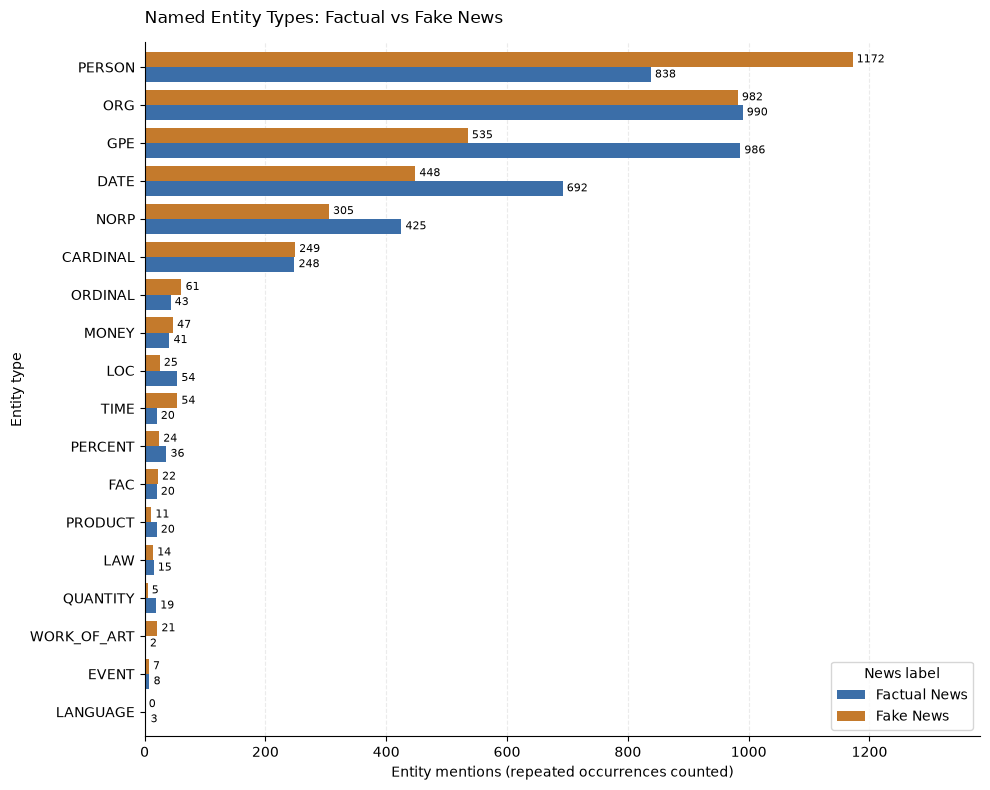

In [21]:
# 直接复用已有 NER 排行表，无需重复调用 spaCy。
# 每列是一组新闻，每行是一种实体类型。
ner_type_comparison = pd.concat(
    {group: ner_type_rankings[group].set_index("Entity Type")["Count"]
     for group in NEWS_GROUPS},
    axis=1,
).fillna(0).astype(int)

# 某类实体在一组中没有出现时记为 0；按合计次数升序排列，
# barh 会把最高频的类型显示在图的顶部。
type_order = ner_type_comparison.sum(axis=1).sort_values().index
ner_type_comparison = ner_type_comparison.loc[type_order]

figure, axis = plt.subplots(figsize=(10, 8))
ner_type_comparison.plot.barh(
    ax=axis,
    color=[label_colors[group] for group in NEWS_GROUPS],
    width=0.8,
)
axis.set_title("Named Entity Types: Factual vs Fake News", loc="left", pad=14)
axis.set_xlabel("Entity mentions (repeated occurrences counted)")
axis.set_ylabel("Entity type")
axis.set_xlim(0, ner_type_comparison.to_numpy().max() * 1.18)
axis.grid(axis="x", linestyle="--", alpha=0.25)
axis.set_axisbelow(True)
axis.spines[["top", "right"]].set_visible(False)
axis.legend(title="News label", loc="lower right")
for bars in axis.containers:
    axis.bar_label(bars, padding=3, fontsize=8)
figure.tight_layout()
plt.show()

### 两组高频实体分别排行

分别展示真、假新闻中前 15 个“实体类型 + 实体文本”组合，沿用表格的排序。同名实体若被模型分到不同类型，会分别展示，例如 `Trump [ORG]` 与 `Trump [PERSON]`。

两张子图使用相同横轴范围；模型的原始预测中可能包含误标，图表不自动纠正标签或合并别名。

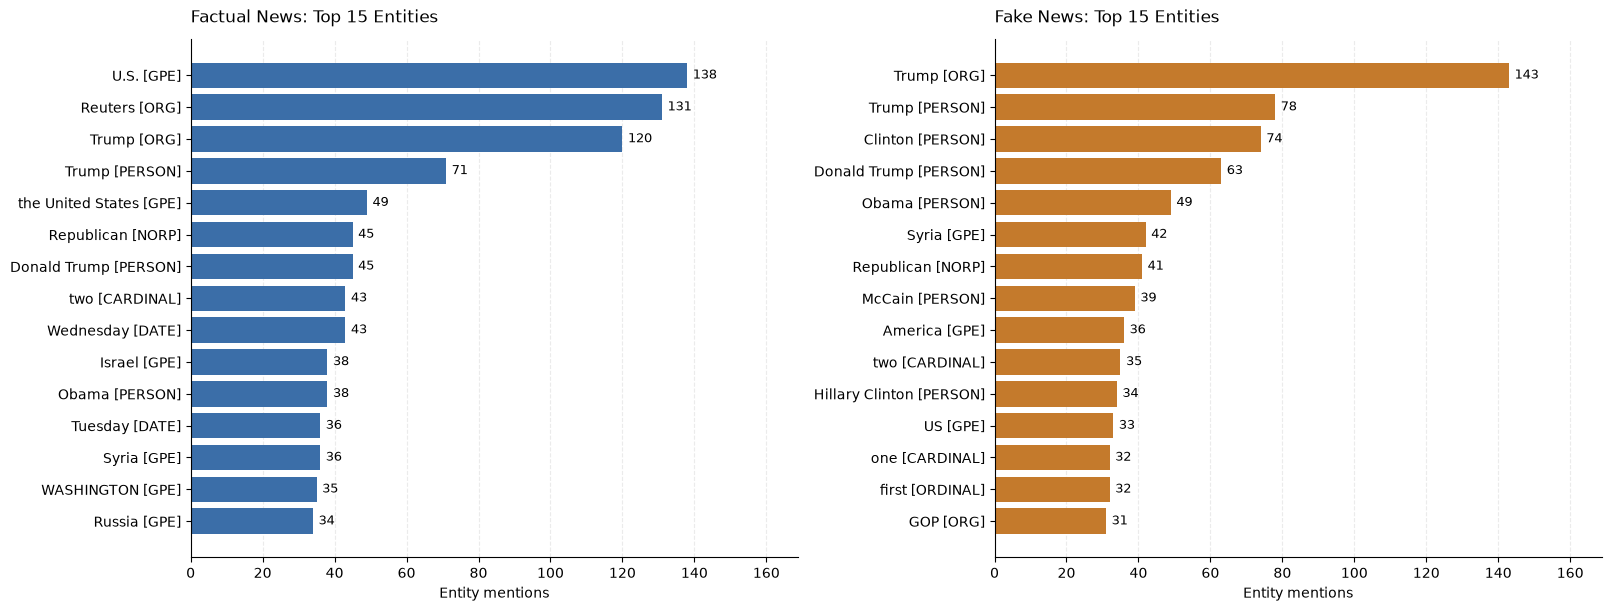

In [22]:
# 修改这个参数可调整图中展示的实体数量。
ner_plot_tables = {
    group: ner_entity_rankings[group].head(NER_PLOT_TOP_N).copy()
    for group in NEWS_GROUPS
}

# 统一横轴上限，让两张图中相同长度的柱子代表相同次数。
largest_count = max(table["Count"].max() for table in ner_plot_tables.values())
figure, axes = plt.subplots(
    1, 2, figsize=(16, max(6, NER_PLOT_TOP_N * 0.38)),
    sharex=True, layout="constrained",
)
for axis, group in zip(axes, NEWS_GROUPS):
    table = ner_plot_tables[group]
    # 标签保留完整实体文本及类型；用数字位置绘图，避免重复文本重叠。
    labels = table["Entity"] + " [" + table["Entity Type"] + "]"
    bars = axis.barh(range(len(table)), table["Count"], color=label_colors[group])
    axis.set_yticks(range(len(table)), labels)
    axis.invert_yaxis()  # 排行表第一行显示在最上方，保持并列项顺序一致。
    axis.set_title(f"{group}: Top {len(table)} Entities", loc="left", pad=12)
    axis.set_xlabel("Entity mentions")
    axis.set_xlim(0, largest_count * 1.18)
    axis.bar_label(bars, padding=4, fontsize=9)
    axis.grid(axis="x", linestyle="--", alpha=0.25)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)
plt.show()

## 15. 核对统计范围

确认每条新闻均已处理、两组的统计次数与模型明细一致，以及源文件没有变化。

In [23]:
assert len(news_docs) == len(news_data)
for news_type in NEWS_GROUPS:
    group_mask = news_analysis[LABEL_COLUMN].eq(news_type)
    group_docs = [doc for doc, selected in zip(news_docs, group_mask) if selected]
    expected_tokens = sum(sum(not token.is_space for token in doc) for doc in group_docs)
    expected_entities = sum(len(doc.ents) for doc in group_docs)
    assert pos_rankings[news_type]["Count"].sum() == expected_tokens
    assert ner_type_rankings[news_type]["Count"].sum() == expected_entities
    assert ner_entity_rankings[news_type]["Count"].sum() == expected_entities
    print(f"{news_type}：{len(group_docs)} 篇，{expected_tokens:,} 个 Token，{expected_entities:,} 次实体提及")

assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_hash_before
pd.testing.assert_frame_equal(news_data, news_data_snapshot)
print("统计核对完成，源数据未改写。")

Factual News：100 篇，39,924 个 Token，4,460 次实体提及
Fake News：98 篇，44,790 个 Token，3,982 次实体提及
统计核对完成，源数据未改写。


## 16. 正文预处理：小写、去标点、停用词与 Token

每行始终对应一篇新闻，处理结果放在独立的 `processed_news` 中。停用词使用 NLTK 英文词表，并延续之前的规则保留 `not`。

按当前步骤，去标点后用空格拆分来匹配停用词，再生成 Token 列表。用空格替换标点可避免连字符两侧的词粘连；缩写也可能被拆开，这份清洗文本用于词语分析。

In [24]:
# 只复制需要的列；原始 news_data 和 CSV 保持不变。
processed_news = news_data[["title", TEXT_COLUMN, LABEL_COLUMN]].copy()
en_stopwords = set(stopwords.words("english")) - {"not"}

def remove_punctuation(text):
    """将英文和 Unicode 标点替换为空格，再合并连续空格。"""
    characters = (
        " " if char in string.punctuation or unicodedata.category(char).startswith("P")
        else char for char in text
    )
    return " ".join("".join(characters).split())

processed_news["lowercase"] = processed_news[TEXT_COLUMN].str.lower()
processed_news["no_punctuation"] = processed_news["lowercase"].apply(remove_punctuation)
# split 按空格拆词，用于精确匹配停用词，避免误删词中的子串。
processed_news["no_stopwords"] = processed_news["no_punctuation"].apply(
    lambda text: " ".join(word for word in text.split() if word not in en_stopwords)
)
processed_news["tokens_clean"] = processed_news["no_stopwords"].str.split()
processed_news[["title", "tokens_clean"]].head(PREVIEW_ROWS)

,title,tokens_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,"[two, small, problems, analogy, susan, jesus, ..."
1,Elijah Cummings Called Trump Out To His Face ...,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"[women, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,"[washington, reuters, u, defense, secretary, j..."
4,Britain says window to restore Northern Irelan...,"[belfast, reuters, northern, ireland, politica..."


## 17. 词形还原与二元组

使用 spaCy 的词形还原组件，保留词性相关组件以辅助判断词形。清洗后的上下文有所减少，词形还原结果也可能不完美。

`bigrams` 中每个二元组由清洗、还原后相邻的两个词组成，绝不跨新闻连接；删除停用词后形成的相邻关系可能不同于原句。

In [25]:
# 前面的 POS/NER 调用仅临时禁用了 lemmatizer，此处重新启用它。
lemma_docs = nlp.pipe(
    processed_news["no_stopwords"].tolist(), batch_size=16,
    disable=["parser", "ner"],
)
processed_news["tokens_lemmatized"] = [
    [token.lemma_.lower() for token in doc if not token.is_space and not token.is_punct]
    for doc in lemma_docs
]
# 每行独立生成二元组；不足两个词的新闻得到空列表。
processed_news["bigrams"] = processed_news["tokens_lemmatized"].apply(
    lambda tokens: list(ngrams(tokens, 2))
)
tokens_clean_list = processed_news["tokens_clean"].tolist()
tokens_lemmatized_list = processed_news["tokens_lemmatized"].tolist()
bigrams_list = processed_news["bigrams"].tolist()
processed_news[["title", "tokens_lemmatized", "bigrams"]].head(PREVIEW_ROWS)

,title,tokens_lemmatized,bigrams
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,"[two, small, problem, analogy, susan, jesus, n...","[(two, small), (small, problem), (problem, ana..."
1,Elijah Cummings Called Trump Out To His Face ...,"[bury, trump, bonker, interview, new, york, ti...","[(bury, trump), (trump, bonker), (bonker, inte..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"[woman, make, 50, percent, country, grossly, u...","[(woman, make), (make, 50), (50, percent), (pe..."
3,Russian bombing of U.S.-backed forces being di...,"[washington, reuters, u, defense, secretary, j...","[(washington, reuters), (reuters, u), (u, defe..."
4,Britain says window to restore Northern Irelan...,"[belfast, reuters, northern, ireland, politica...","[(belfast, reuters), (reuters, northern), (nor..."


### 17.1 一元组与 N-gram 频率统计

一元组是单个词组成的元组，例如 `('news',)`；二元组是两个相邻词，例如 `('fake', 'news')`。两者均基于 `tokens_lemmatized`，每篇新闻独立生成，然后在各真假类别内汇总次数。

统计包含重复出现的次数，不是包含该词的新闻篇数。二元组的邻接关系来自清洗后的词序列。

In [26]:
# 与二元组相同，每一行的一元组列表对应一篇新闻。
processed_news["unigrams"] = processed_news["tokens_lemmatized"].apply(
    lambda tokens: list(ngrams(tokens, 1))
)
unigrams_list = processed_news["unigrams"].tolist()

# 字典结构：ngram_rankings["unigrams"或"bigrams"][真假新闻标签]。
ngram_rankings = {"unigrams": {}, "bigrams": {}}
for column in ngram_rankings:
    for group in NEWS_GROUPS:
        # explode 仅展开已经在每篇新闻内生成的元组，因此不会跨新闻拼词。
        items = processed_news.loc[
            processed_news[LABEL_COLUMN] == group, column
        ].explode().dropna()
        counts = items.value_counts().rename_axis("N-gram").reset_index(name="Count")
        # 同频时按元组排序，确保结果顺序稳定；Rank 保留并列名次。
        counts = counts.sort_values(["Count", "N-gram"], ascending=[False, True]).reset_index(drop=True)
        counts.insert(0, "Rank", counts["Count"].rank(method="min", ascending=False).astype(int))
        ngram_rankings[column][group] = counts

processed_news[["title", "unigrams", "bigrams"]].head(PREVIEW_ROWS)

,title,unigrams,bigrams
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,"[(two,), (small,), (problem,), (analogy,), (su...","[(two, small), (small, problem), (problem, ana..."
1,Elijah Cummings Called Trump Out To His Face ...,"[(bury,), (trump,), (bonker,), (interview,), (...","[(bury, trump), (trump, bonker), (bonker, inte..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"[(woman,), (make,), (50,), (percent,), (countr...","[(woman, make), (make, 50), (50, percent), (pe..."
3,Russian bombing of U.S.-backed forces being di...,"[(washington,), (reuters,), (u,), (defense,), ...","[(washington, reuters), (reuters, u), (u, defe..."
4,Britain says window to restore Northern Irelan...,"[(belfast,), (reuters,), (northern,), (ireland...","[(belfast, reuters), (reuters, northern), (nor..."


### 17.2 通用 N-gram 排行图

每幅图分别展示真、假新闻，使用相同横轴刻度，柱顶标注次数。一元组和二元组共用绘图函数；表格保留元组，图中用空格连接以便阅读。

In [27]:
def plot_ngram_rankings(rankings, name):
    """绘制两组前 N 名；输入为按真假标签存储的频率表字典。"""
    largest = max((table["Count"].max() for table in rankings.values() if not table.empty), default=1)
    figure, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, layout="constrained")
    for axis, group in zip(axes, NEWS_GROUPS):
        table = rankings[group].head(NGRAM_TOP_N)
        labels = table["N-gram"].map(" ".join)
        bars = axis.barh(range(len(table)), table["Count"], color=label_colors[group])
        axis.set_yticks(range(len(table)), labels)
        axis.invert_yaxis()
        axis.set_title(f"{group}: Top {len(table)} {name}")
        axis.set_xlabel("Occurrences in cleaned text")
        axis.set_xlim(0, max(1, largest) * 1.2)
        axis.bar_label(bars, padding=4)
        axis.grid(axis="x", alpha=0.2)
        axis.set_axisbelow(True)
        axis.spines[["top", "right"]].set_visible(False)
    plt.show()

### Unigrams 前 15 名及可视化

In [28]:
# Factual News：完整频率表保存在 ngram_rankings 中。
ngram_rankings["unigrams"]["Factual News"].head(NGRAM_TOP_N)

,Rank,N-gram,Count
0,1,"(say,)",506
1,2,"(trump,)",268
2,3,"(u,)",200
3,4,"(not,)",161
4,5,"(president,)",141
5,6,"(would,)",129
6,7,"(state,)",117
7,8,"(reuters,)",101
8,9,"(year,)",97
9,10,"(house,)",83


In [29]:
# Fake News：完整频率表保存在 ngram_rankings 中。
ngram_rankings["unigrams"]["Fake News"].head(NGRAM_TOP_N)

,Rank,N-gram,Count
0,1,"(trump,)",344
1,2,"(say,)",208
2,3,"(not,)",202
3,4,"(president,)",134
4,5,"(clinton,)",121
5,6,"(go,)",120
6,7,"(one,)",104
7,8,"(would,)",98
8,9,"(make,)",91
9,10,"(state,)",90


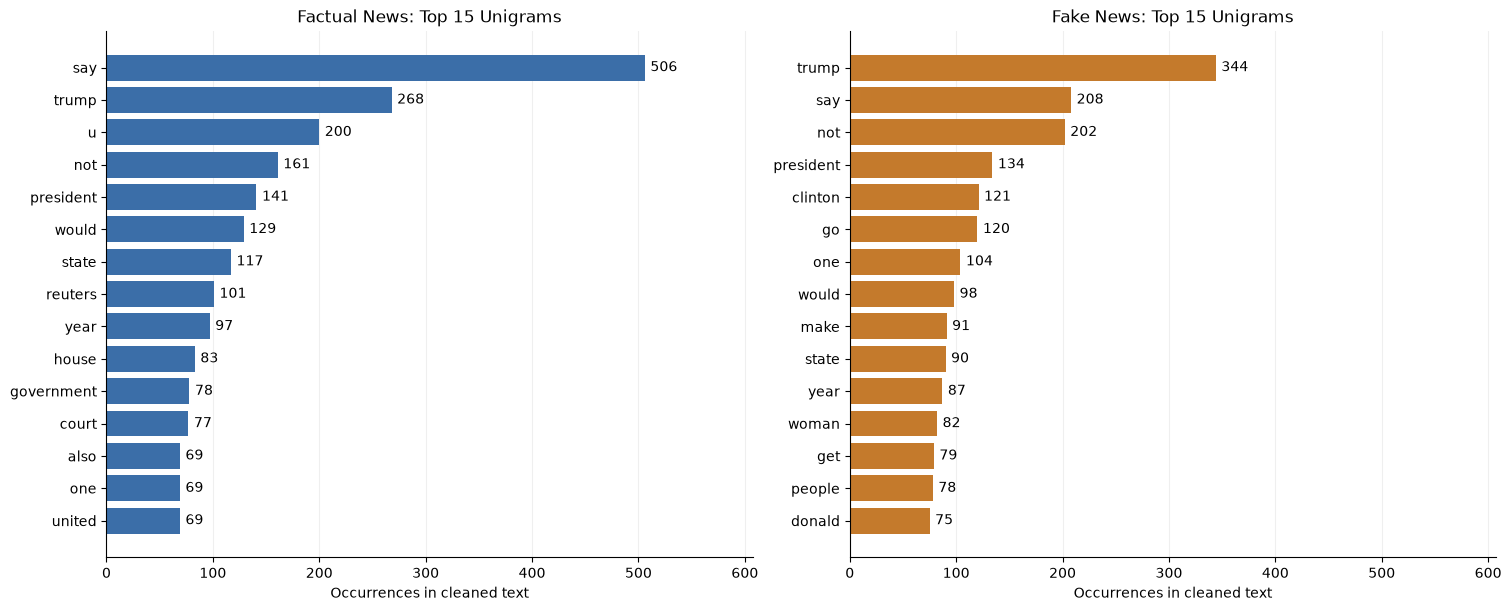

In [30]:
plot_ngram_rankings(ngram_rankings["unigrams"], "Unigrams")

### Bigrams 前 15 名及可视化

In [31]:
# Factual News：完整频率表保存在 ngram_rankings 中。
ngram_rankings["bigrams"]["Factual News"].head(NGRAM_TOP_N)

,Rank,N-gram,Count
0,1,"(united, states)",55
1,2,"(donald, trump)",50
2,3,"(white, house)",48
3,4,"(president, donald)",39
4,5,"(washington, reuters)",33
5,6,"(official, say)",28
6,7,"(reuters, u)",23
7,8,"(attorney, general)",21
8,8,"(new, york)",21
9,8,"(tell, reporter)",21


In [32]:
# Fake News：完整频率表保存在 ngram_rankings 中。
ngram_rankings["bigrams"]["Fake News"].head(NGRAM_TOP_N)

,Rank,N-gram,Count
0,1,"(donald, trump)",65
1,2,"(hillary, clinton)",34
2,3,"(feature, image)",30
3,4,"(image, via)",29
4,4,"(white, house)",29
5,6,"(united, states)",28
6,7,"(food, stamp)",26
7,7,"(pic, twitter)",26
8,7,"(twitter, com)",26
9,10,"(trump, supporter)",24


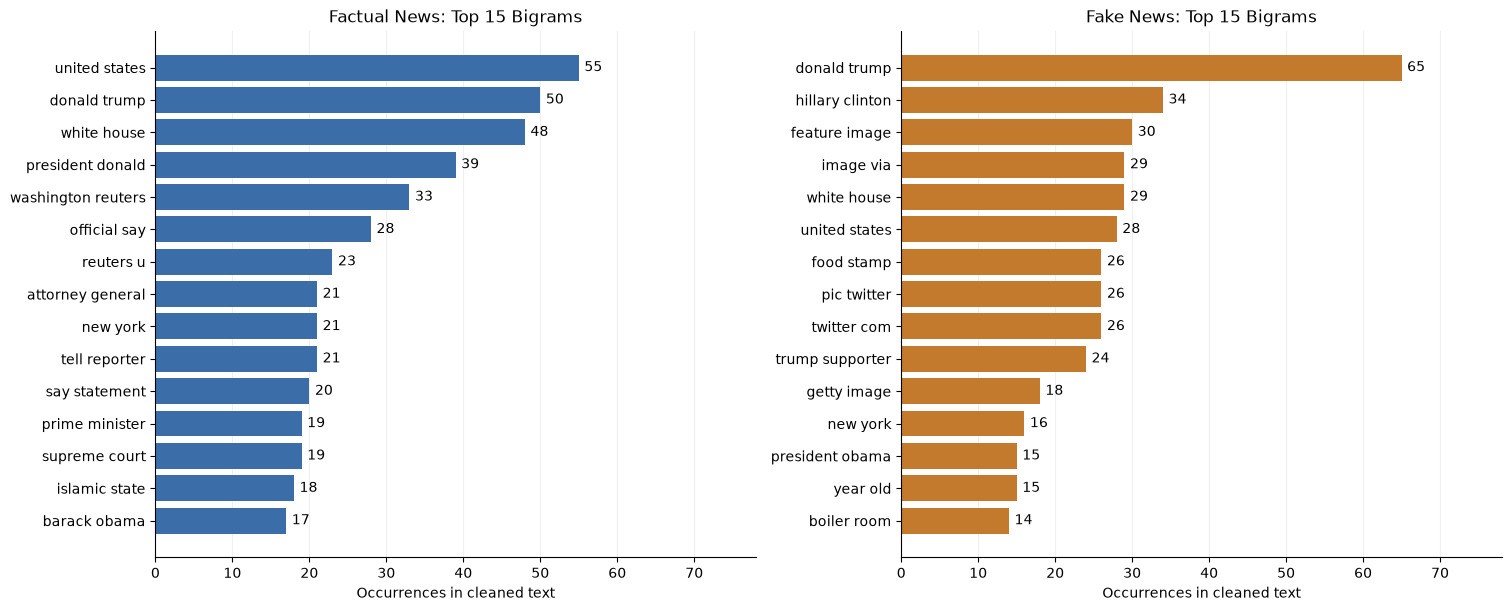

In [33]:
plot_ngram_rankings(ngram_rankings["bigrams"], "Bigrams")

In [34]:
# 核对 N-gram 总次数与各篇新闻列表长度，确保统计没有漏计或重复连接。
for column in ngram_rankings:
    for group in NEWS_GROUPS:
        expected = processed_news.loc[processed_news[LABEL_COLUMN] == group, column].map(len).sum()
        assert ngram_rankings[column][group]["Count"].sum() == expected
assert all(len(words) == len(tokens) for words, tokens in zip(unigrams_list, tokens_lemmatized_list))
print("一元组和二元组数量核对通过。")

一元组和二元组数量核对通过。


## 18. VADER 新闻情感评分与分类

使用**原始正文**调用 `SentimentIntensityAnalyzer()`，保留其所需的否定词、大小写和标点信号。

本次采用整篇正文一次评分的简易基线。`compound` 在 -1 到 1 之间，按 [VADER 官方规则](https://github.com/cjhutto/vaderSentiment#about-the-scoring)分类：≥ 0.05 为正面，≤ -0.05 为负面，其余为中性（正常）。`pos`、`neg`、`neu` 是情感成分分值，不是新闻分类的置信概率。

长新闻可能包含混合情绪，整篇分数会掩盖句子差异；情绪正负不表示新闻真假。

In [35]:
sentiment_analyzer = SentimentIntensityAnalyzer()

# 每篇新闻得到 neg、neu、pos 和 compound 四个分值。
scores = pd.DataFrame(
    processed_news[TEXT_COLUMN].apply(sentiment_analyzer.polarity_scores).tolist(),
    index=processed_news.index,
)
def classify_sentiment(compound):
    """将综合情感分数映射为三类，包含阈值边界。"""
    if compound >= POSITIVE_THRESHOLD:
        return "正面"
    if compound <= NEGATIVE_THRESHOLD:
        return "负面"
    return "中性（正常）"

sentiment_results = processed_news[["title", LABEL_COLUMN]].join(scores)
sentiment_results["sentiment"] = sentiment_results["compound"].apply(classify_sentiment)
sentiment_results.head(PREVIEW_ROWS)

,title,fake_or_factual,neg,neu,pos,compound,sentiment
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,Fake News,0.076,0.854,0.069,-0.3660,负面
1,Elijah Cummings Called Trump Out To His Face ...,Fake News,0.103,0.817,0.080,-0.8197,负面
2,Hillary Clinton Says Half Her Cabinet Will Be...,Fake News,0.048,0.850,0.102,0.9779,正面
3,Russian bombing of U.S.-backed forces being di...,Factual News,0.090,0.841,0.069,-0.3400,负面
4,Britain says window to restore Northern Irelan...,Factual News,0.024,0.844,0.131,0.8590,正面


## 19. 真、假新闻情绪数量与占比

每篇新闻只计一次。保留三种情绪，即使某组没有中性新闻也展示为零。占比使用各组新闻篇数作分母，便于比较。

In [36]:
sentiment_counts = pd.crosstab(
    sentiment_results[LABEL_COLUMN], sentiment_results["sentiment"]
).reindex(index=NEWS_GROUPS, columns=SENTIMENT_ORDER, fill_value=0)
sentiment_percentages = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0).mul(100)
sentiment_counts

sentiment,正面,负面,中性（正常）
fake_or_factual,,,
Factual News,52,47,1
Fake News,47,46,5


In [37]:
sentiment_percentages.round(2)

sentiment,正面,负面,中性（正常）
fake_or_factual,,,
Factual News,52.00,47.00,1.0
Fake News,47.96,46.94,5.1


### 情绪可视化

两张子图分别展示真、假新闻；使用相同纵轴范围，柱顶标注数量和组内占比。图表采用英文标签避免字体缺字：Positive=正面，Negative=负面，Neutral=中性（正常）。

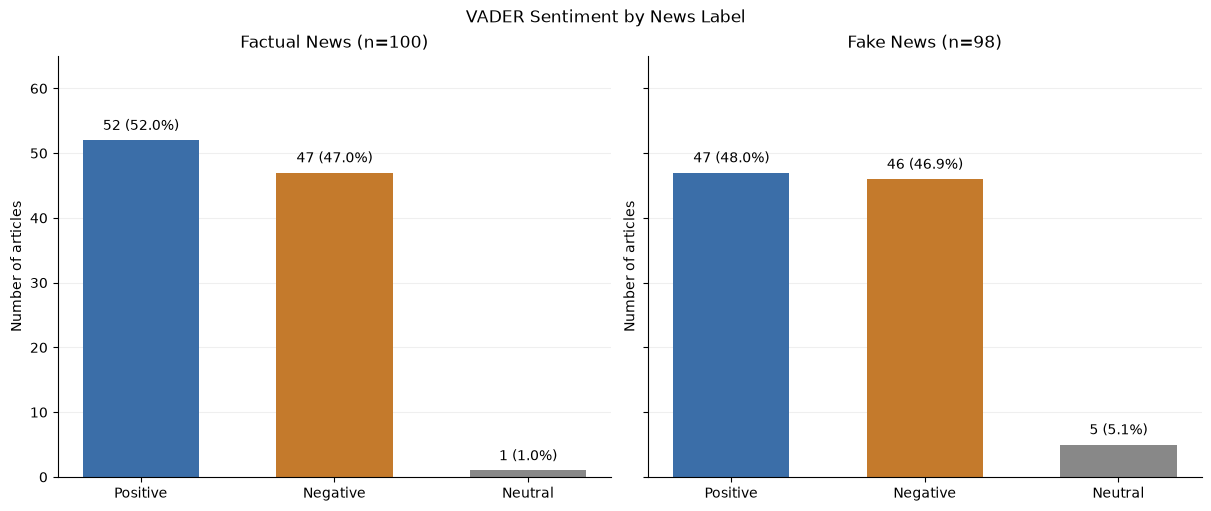

In [38]:
figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, layout="constrained")
for axis, group in zip(axes, NEWS_GROUPS):
    counts = sentiment_counts.loc[group]
    percentages = sentiment_percentages.loc[group]
    bars = axis.bar(["Positive", "Negative", "Neutral"], counts,
                    color=["#3B6EA8", "#C47A2C", "#888888"], width=0.6)
    axis.set_title(f"{group} (n={counts.sum()})")
    axis.set_ylabel("Number of articles")
    axis.set_ylim(0, max(1, sentiment_counts.to_numpy().max()) * 1.25)
    axis.bar_label(bars, labels=[f"{count} ({share:.1f}%)"
                   for count, share in zip(counts, percentages)], padding=5)
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)
figure.suptitle("VADER Sentiment by News Label")
plt.show()

## 20. 核对结果

核对行对应关系、二元组数量、情感分数范围及源数据完整性。

In [39]:
assert processed_news.index.equals(news_data.index)
assert all(len(pairs) == max(len(tokens) - 1, 0)
           for tokens, pairs in zip(tokens_lemmatized_list, bigrams_list))
assert "not" not in en_stopwords
assert sentiment_results["compound"].between(-1, 1).all()
assert sentiment_counts.sum(axis=1).to_dict() == news_data[LABEL_COLUMN].value_counts().to_dict()
pd.testing.assert_frame_equal(news_data, news_data_snapshot)
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_hash_before
print("文本预处理、情绪统计和源数据检查通过。")

文本预处理、情绪统计和源数据检查通过。


## 21. 主题建模：共用语料和参数

本次将全部真假新闻正文一起建模，不使用真假标签训练。主题编号不是真假类别，也不自动等于一个有名称的新闻话题。

基于 `tokens_lemmatized` 创建独立语料，去掉非字母及单字符 Token；过滤仅出现于一篇或超过 80% 新闻的词。两种方法使用相同词典、新闻和关键词数量，便于比较。

遍历 2～11 个主题，以训练语料的 `c_v` 一致性评分（越高越好）辅助选择。固定随机种子用于课程复现；这不是测试集准确率，也不是对全局最佳主题数的证明。

参考：[gensim 一致性评分](https://radimrehurek.com/gensim/models/coherencemodel.html)、[LSI](https://radimrehurek.com/gensim/models/lsimodel.html)。

In [40]:
# 使用副本，不改变已有清洗结果或源新闻。
topic_texts = [[word for word in tokens if word.isalpha() and len(word) > 1]
               for tokens in tokens_lemmatized_list]
topic_dictionary = Dictionary(topic_texts)
topic_dictionary.filter_extremes(no_below=2, no_above=0.8, keep_n=None)
topic_texts = [[word for word in words if word in topic_dictionary.token2id]
               for words in topic_texts]

# 过滤后空文档不能提供主题信息；保留索引，方便回查原始新闻。
topic_news_indices = [index for index, words in zip(processed_news.index, topic_texts) if words]
topic_texts = [words for words in topic_texts if words]
assert min(len(topic_dictionary), len(topic_texts)) > max(TOPIC_COUNTS)

# doc2bow 返回 (词编号, 出现次数) 的稀疏列表，不创建庞大的密集矩阵。
bow_corpus = [topic_dictionary.doc2bow(words) for words in topic_texts]
tfidf_model = TfidfModel(bow_corpus, dictionary=topic_dictionary)
tfidf_corpus = list(tfidf_model[bow_corpus])
print(f"用于建模：{len(topic_texts)} 篇；词典：{len(topic_dictionary)} 个词；排除空文档：{len(processed_news)-len(topic_texts)} 篇")
pd.DataFrame({"Word": [topic_dictionary[word_id] for word_id, count in bow_corpus[0][:10]],
              "BoW Count": [count for word_id, count in bow_corpus[0][:10]]})

用于建模：198 篇；词典：3285 个词；排除空文档：0 篇


,Word,BoW Count
0,accompany,1
1,actor,1
2,aid,1
3,also,1
4,american,1
5,anyone,1
6,apparently,1
7,appear,1
8,approach,1
9,arrive,1


### 主题模型共用函数

统一一致性评分和文档主题矩阵转换，LDA、LSI 及手动主题数共用。

In [41]:
def topic_coherence(model, count, texts, dictionary, topn):
    """提取指定数量的主题关键词，计算相同口径的 c_v 一致性。

    texts 是分词后的文档列表，dictionary 是共享词典；返回一个浮点分数。
    LSI 关键词按绝对权重选取，其正负方向的局限在主题章节单独说明。
    processes=1 避免 Notebook 在 Windows 上额外启动子进程。
    """
    keywords = [[word for word, weight in model.show_topic(i, topn=topn)]
                for i in range(count)]
    return CoherenceModel(topics=keywords, texts=texts, dictionary=dictionary,
                          coherence="c_v", processes=1).get_coherence()


def document_topic_matrix(model, corpus, count, lda=False):
    """把稀疏的 (主题编号, 权重) 转成文档×主题矩阵，保留文档顺序。

    LDA 显式返回全部概率；LSI 未返回的维度补零，保留正负号。
    使用主题编号定位列，不依赖 gensim 返回元组的排列顺序。
    """
    matrix = np.zeros((len(corpus), count))
    for row, doc in enumerate(corpus):
        weights = model.get_document_topics(doc, minimum_probability=0) if lda else model[doc]
        for topic, weight in weights:
            matrix[row, topic] = weight
    return matrix

## 22. 方法一：词袋模型 + LDA

LDA 接收词频计数，学习每个主题的词概率分布。对每个候选主题数保存模型和一致性分数，避免选定之后重新训练。

In [42]:
lda_models = {}
lda_scores = []
for count in TOPIC_COUNTS:
    model = LdaModel(
        corpus=bow_corpus, id2word=topic_dictionary, num_topics=count,
        random_state=TOPIC_SEED, passes=LDA_PASSES, iterations=100,
    )
    score = topic_coherence(model, count, topic_texts, topic_dictionary, TOPIC_WORDS)
    lda_models[count] = model
    lda_scores.append({"Topics": count, "Coherence c_v": score})
    print(f"LDA {count} topics: {score:.4f}")
lda_comparison = pd.DataFrame(lda_scores)
lda_comparison

LDA 2 topics: 0.3813


LDA 3 topics: 0.3390


LDA 4 topics: 0.3388


LDA 5 topics: 0.3611


LDA 6 topics: 0.3545


...

LDA 8 topics: 0.3775


LDA 9 topics: 0.3504


LDA 10 topics: 0.3511


LDA 11 topics: 0.3470


,Topics,Coherence c_v
0,2,0.381275
1,3,0.338994
2,4,0.338820
3,5,0.361147
4,6,0.354525
5,7,0.353815
6,8,0.377461
7,9,0.350352
8,10,0.351130
9,11,0.347049


## 23. 方法二：TF-IDF + LSA/LSI

LSA 和 LSI 在这里使用同一种截断奇异值分解方法。TF-IDF 为词频加权，LSI 的维度有正负方向，权重不是概率。

为了画候选数曲线，用每个维度绝对权重最大的 10 个词计算 `c_v`。这会混合正负方向，因此仅作启发式参考；后面同时展示带符号权重，人工判断含义。不能仅按两种方法的分数大小宣布谁更准确。

In [43]:
lsi_models = {}
lsi_scores = []
for count in TOPIC_COUNTS:
    model = LsiModel(corpus=tfidf_corpus, id2word=topic_dictionary,
                     num_topics=count, random_seed=TOPIC_SEED)
    # LSI show_topic 按权重绝对值提取重要词，保留返回的正负权重。
    actual_count = model.get_topics().shape[0]
    assert actual_count == count, "有效矩阵秩不足，请降低主题数范围"
    score = topic_coherence(model, count, topic_texts, topic_dictionary, TOPIC_WORDS)
    lsi_models[count] = model
    lsi_scores.append({"Topics": count, "Coherence c_v": score})
    print(f"LSI {count} topics: {score:.4f}")
lsi_comparison = pd.DataFrame(lsi_scores)
lsi_comparison

LSI 2 topics: 0.7138
LSI 3 topics: 0.6148


LSI 4 topics: 0.5310


LSI 5 topics: 0.4961


LSI 6 topics: 0.4667


LSI 7 topics: 0.4487


LSI 8 topics: 0.4495


LSI 9 topics: 0.4387


LSI 10 topics: 0.4140


LSI 11 topics: 0.4086


,Topics,Coherence c_v
0,2,0.713802
1,3,0.614760
2,4,0.531015
3,5,0.496125
4,6,0.466667
5,7,0.448677
6,8,0.449480
7,9,0.438734
8,10,0.414011
9,11,0.408593


## 24. 可视化 2～11 个主题并选择候选

分别绘制评分曲线，星号标出本次最大值。完全同分时选择更小的主题数。若最佳值落在端点，它仅是当前搜索范围内的最佳候选。

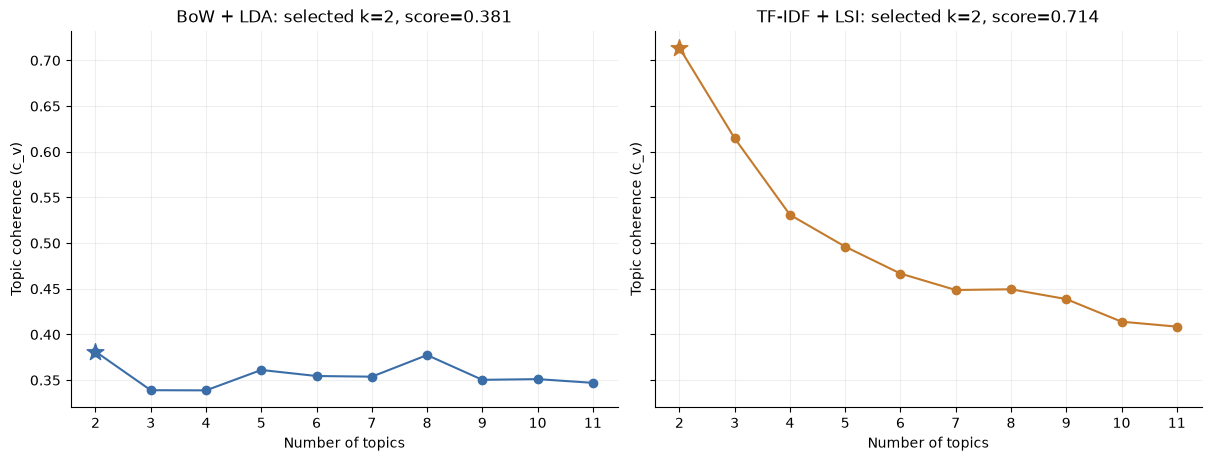

当前候选：LDA=2 个主题；LSI=2 个维度。


In [44]:
best_lda_k = int(lda_comparison.sort_values(["Coherence c_v", "Topics"], ascending=[False, True]).iloc[0]["Topics"])
best_lsi_k = int(lsi_comparison.sort_values(["Coherence c_v", "Topics"], ascending=[False, True]).iloc[0]["Topics"])
best_lda_model = lda_models[best_lda_k]
best_lsi_model = lsi_models[best_lsi_k]

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, layout="constrained")
for axis, table, best_k, name, color in [
    (axes[0], lda_comparison, best_lda_k, "BoW + LDA", "#3B6EA8"),
    (axes[1], lsi_comparison, best_lsi_k, "TF-IDF + LSI", "#C47A2C"),
]:
    axis.plot(table["Topics"], table["Coherence c_v"], marker="o", color=color)
    best_score = table.loc[table["Topics"] == best_k, "Coherence c_v"].iloc[0]
    axis.scatter([best_k], [best_score], marker="*", s=160, color=color, zorder=3)
    axis.set_title(f"{name}: selected k={best_k}, score={best_score:.3f}")
    axis.set_xticks(TOPIC_COUNTS)
    axis.set_xlabel("Number of topics")
    axis.set_ylabel("Topic coherence (c_v)")
    axis.grid(alpha=0.2)
    axis.spines[["top", "right"]].set_visible(False)
plt.show()
print(f"当前候选：LDA={best_lda_k} 个主题；LSI={best_lsi_k} 个维度。")

## 25. 用 gensim 查看选中模型的主题

下面调用 `show_topics()` 展示关键词和权重。LDA 权重是词概率；LSI 权重有正负号，两端可能反映不同内容，不能当成概率相加。主题名称需阅读这些关键词和原文后确定。

In [45]:
def describe_topics(model, count):
    """将 gensim 的主题列表转换为便于阅读的表格，保留权重。"""
    return pd.DataFrame([
        {"Topic ID": topic_id,
         "Keywords and weights": "; ".join(f"{word} ({weight:+.3f})" for word, weight in terms)}
        for topic_id, terms in model.show_topics(num_topics=count, num_words=TOPIC_WORDS, formatted=False)
    ])

lda_topics = describe_topics(best_lda_model, best_lda_k)
# 仅在当前展示时放宽列宽，避免关键词被截断。
display_full_table(lda_topics)

,Topic ID,Keywords and weights
0,0,trump (+0.009); not (+0.009); president (+0.006); year (+0.006); would (+0.006); state (+0.005); obama (+0.004); court (+0.004); government (+0.004); make (+0.004)
1,1,trump (+0.022); not (+0.009); president (+0.007); clinton (+0.006); state (+0.006); would (+0.006); donald (+0.005); one (+0.005); tell (+0.004); official (+0.004)


In [46]:
lsi_topics = describe_topics(best_lsi_model, best_lsi_k)
display_full_table(lsi_topics)

,Topic ID,Keywords and weights
0,0,trump (-0.199); clinton (-0.133); bill (-0.096); woman (-0.091); obama (-0.089); vote (-0.086); court (-0.086); hillary (-0.079); tax (-0.077); president (-0.077)
1,1,boiler (+0.383); acr (+0.314); room (+0.276); pm (+0.265); radio (+0.199); broadcast (+0.174); animal (+0.145); jay (+0.139); tune (+0.138); join (+0.138)


### 回查每个主题的代表新闻

LDA 按主题概率挑选代表新闻；LSI 按该维度系数的绝对值挑选，同时保留正负号。每个主题展示两篇，允许同一篇新闻出现在多个主题中。

In [47]:
lda_document_topics = document_topic_matrix(best_lda_model, bow_corpus, best_lda_k, lda=True)
lsi_document_topics = document_topic_matrix(best_lsi_model, tfidf_corpus, best_lsi_k)

def representative_news(matrix, signed=False):
    """保留源新闻索引和标题，帮助人工理解主题。"""
    rows = []
    for topic in range(matrix.shape[1]):
        values = matrix[:, topic]
        positions = np.argsort(-(np.abs(values) if signed else values), kind="stable")[:2]
        for position in positions:
            index = topic_news_indices[position]
            rows.append({"Topic ID": topic, "News Index": index,
                         "Weight": float(values[position]), "Title": news_data.loc[index, "title"]})
    return pd.DataFrame(rows)

lda_representatives = representative_news(lda_document_topics)
lsi_representatives = representative_news(lsi_document_topics, signed=True)
display(lda_representatives)
display(lsi_representatives)

assert len(lda_comparison) == len(lsi_comparison) == 10
assert np.isfinite(lda_comparison["Coherence c_v"]).all()
assert np.isfinite(lsi_comparison["Coherence c_v"]).all()
assert np.allclose(lda_document_topics.sum(axis=1), 1, atol=1e-5)
pd.testing.assert_frame_equal(news_data, news_data_snapshot)
print("两种方法均完成 2～11 个主题的比较，源数据保持不变。")

,Topic ID,News Index,Weight,Title
0,0,170,0.998545,"Factbox: Divided, rebellious UK parliament tak..."
1,0,13,0.998540,TOP FIVE Food Stamp Fraud Takedowns of 2017…Do...
2,1,136,0.999414,John McCain and The Cancer of Conflict
3,1,157,0.998427,Israel hits Syrian site said to be linked to c...


,Topic ID,News Index,Weight,Title
0,0,79,-0.380112,Legal battle over travel ban pits Trump's powe...
1,0,84,-0.362607,Locker room talk? Key women voters call foul o...
2,1,19,0.908115,Boiler Room #104 – War Sells… But Who’s Buying
3,1,16,0.882899,Boiler Room #88 – Behold: Your New Ministry of...


两种方法均完成 2～11 个主题的比较，源数据保持不变。


## 26. 手动查看 8 个主题

这里选择 8 个主题作人工比较，前面的自动评分结果保留。直接取出候选模型中的 8 主题版本；主题编号为 0～7。

LDA 表中的权重为词概率，LSI 为有正负号的维度权重。结合每个主题的代表新闻判断含义，而不是把 8 个主题当作已确认的新闻类别。

In [48]:
# 后续想查看其他已训练的主题数，只需修改这里（2～11）。
view_lda_model = lda_models[VIEW_TOPIC_COUNT]
view_lsi_model = lsi_models[VIEW_TOPIC_COUNT]
lda_topics_8 = describe_topics(view_lda_model, VIEW_TOPIC_COUNT)
lsi_topics_8 = describe_topics(view_lsi_model, VIEW_TOPIC_COUNT)

### LDA：8 个主题的关键词与权重

In [49]:
display_full_table(lda_topics_8)

,Topic ID,Keywords and weights
0,0,trump (+0.013); not (+0.007); president (+0.007); would (+0.007); government (+0.007); year (+0.006); one (+0.006); law (+0.005); know (+0.004); make (+0.004)
1,1,trump (+0.035); not (+0.010); president (+0.009); would (+0.008); campaign (+0.008); take (+0.007); tell (+0.006); donald (+0.006); clinton (+0.006); bill (+0.005)
2,2,tax (+0.012); not (+0.011); president (+0.011); year (+0.009); obama (+0.009); would (+0.009); senate (+0.007); republican (+0.006); bill (+0.005); also (+0.005)
3,3,trump (+0.022); not (+0.010); syria (+0.008); mccain (+0.008); president (+0.008); clinton (+0.007); would (+0.006); vote (+0.006); candidate (+0.005); one (+0.004)
4,4,state (+0.015); military (+0.013); not (+0.008); country (+0.005); myanmar (+0.005); united (+0.005); force (+0.005); government (+0.005); foreign (+0.004); islamic (+0.004)
5,5,court (+0.012); not (+0.010); trump (+0.010); state (+0.008); security (+0.007); president (+0.007); order (+0.007); department (+0.006); official (+0.006); refugee (+0.006)
6,6,student (+0.014); state (+0.010); law (+0.010); not (+0.009); go (+0.007); campus (+0.007); make (+0.007); trump (+0.006); city (+0.006); new (+0.005)
7,7,trump (+0.016); not (+0.007); go (+0.006); president (+0.005); party (+0.005); one (+0.005); woman (+0.005); clinton (+0.005); time (+0.004); also (+0.004)


### LSI：8 个主题的关键词与权重

In [50]:
display_full_table(lsi_topics_8)

,Topic ID,Keywords and weights
0,0,trump (-0.199); clinton (-0.133); bill (-0.096); woman (-0.091); obama (-0.089); vote (-0.086); court (-0.085); hillary (-0.079); tax (-0.077); president (-0.077)
1,1,boiler (+0.382); acr (+0.313); room (+0.277); pm (+0.264); radio (+0.199); broadcast (+0.174); animal (+0.145); jay (+0.139); tune (+0.138); join (+0.138)
2,2,korea (+0.295); china (+0.197); clinton (-0.187); south (+0.185); north (+0.169); putin (+0.143); syria (+0.132); japanese (+0.129); woman (-0.119); korean (+0.119)
3,3,clinton (-0.265); court (+0.250); korea (-0.206); ban (+0.160); hillary (-0.156); order (+0.145); woman (-0.138); south (-0.135); judge (+0.132); china (-0.129)
4,4,putin (-0.306); russian (-0.224); korea (+0.200); comey (-0.194); tax (+0.171); russia (-0.169); china (+0.155); south (+0.150); syria (-0.143); bill (+0.120)
5,5,tax (-0.378); bill (-0.258); court (+0.193); putin (-0.162); clinton (+0.151); senate (-0.145); ban (+0.125); senator (-0.115); mccain (-0.112); employee (-0.109)
6,6,comey (-0.173); court (-0.127); syria (+0.126); manafort (-0.125); korea (-0.119); flynn (-0.116); committee (-0.110); israel (+0.110); mueller (-0.108); russia (-0.103)
7,7,putin (-0.494); court (-0.143); obama (-0.128); supreme (-0.094); manafort (+0.087); china (+0.086); vladimir (-0.084); email (+0.083); history (-0.081); comey (+0.080)


### 8 个主题的代表新闻

每个主题各展示两篇。保留新闻索引，方便回查正文；LSI 根据系数绝对值选取，并显示其符号。

In [51]:
# 复用矩阵转换规则，默认 8 主题结果与自动选中模型的转换方式一致。
lda_document_topics_8 = document_topic_matrix(view_lda_model, bow_corpus, VIEW_TOPIC_COUNT, lda=True)
lsi_document_topics_8 = document_topic_matrix(view_lsi_model, tfidf_corpus, VIEW_TOPIC_COUNT)
lda_representatives_8 = representative_news(lda_document_topics_8)
lsi_representatives_8 = representative_news(lsi_document_topics_8, signed=True)
assert len(lda_topics_8) == len(lsi_topics_8) == VIEW_TOPIC_COUNT

### LDA：代表新闻

In [52]:
display_full_table(lda_representatives_8)

,Topic ID,News Index,Weight,Title
0,0,170,0.998318,"Factbox: Divided, rebellious UK parliament takes on May's Brexit plan"
1,0,13,0.997904,TOP FIVE Food Stamp Fraud Takedowns of 2017…Do You See The Common Thread?
2,1,143,0.997467,Trump allies falsely link Reuters to claim Detroit video feed was cut short
3,1,58,0.997295,"BREAKING: Trump, Rudy Giuliani, Reince Priebus, Sen. Jeff Sessions Travel To Mexico To Meet With President"
4,2,131,0.997677,Silicon Valley blasts Senate proposal to tax startup options
5,2,114,0.997050,"Ted Cruz Repeats Lie About SCOTUS Nominations, Vows To Block Anyone Obama Chooses (VIDEO)"
6,3,136,0.999440,John McCain and The Cancer of Conflict
7,3,59,0.997867,"Saudi air strikes on Yemen intensify, residents in capital stay indoors"
8,4,182,0.997460,Trump's budget proposes converting some military grants to loans
9,4,145,0.997079,"Myanmar, accused of crackdown, invited to U.S.-Thai military exercise"


### LSI：代表新闻

In [53]:
display_full_table(lsi_representatives_8)

,Topic ID,News Index,Weight,Title
0,0,79,-0.380262,Legal battle over travel ban pits Trump's powers against his own words
1,0,84,-0.362421,Locker room talk? Key women voters call foul on Trump's defense
2,1,19,0.907995,Boiler Room #104 – War Sells… But Who’s Buying
3,1,16,0.881337,Boiler Room #88 – Behold: Your New Ministry of Truth
4,2,60,0.507246,"Tillerson underlines cooperation with Japan, Seoul on North Korea"
5,2,81,0.440490,Trump and Japan's Abe agree to keep pressure on North Korea
6,3,12,0.453622,Another U.S. appeals court refuses to revive Trump travel ban
7,3,154,0.440920,Trump asks Supreme Court to block travel ban ruling
8,4,47,-0.394557,BOMBSHELL: COMEY Wanted To Expose Russian Meddling Months Before Election…OBAMA Regime Barred Him From Telling Public [VIDEO]
9,4,135,-0.338046,"Obama, Putin talk about Syria and Ukraine in quick summit meet"


## 27. TF-IDF + 逻辑回归真假新闻分类器

输入为原始 `text`，目标为 `fake_or_factual`，`title` 仅用于查看结果。先分层划分 80% 训练集、20% 测试集，再由 Pipeline 在训练集上学习词典、IDF 和分类器。

前面的全量语料主题模型不参与训练。测试集只用于本次最终评估，不根据测试结果反复调整参数。当前数据量小，测试分数受划分影响，不代表真实场景中的事实核查能力。

In [54]:
# 使用副本，保留原始索引，以便通过索引回查标题。
classification_data = news_data[["title", TEXT_COLUMN, LABEL_COLUMN]].copy()
assert classification_data[[TEXT_COLUMN, LABEL_COLUMN]].notna().all().all()
assert classification_data[TEXT_COLUMN].str.strip().ne("").all()
assert set(classification_data[LABEL_COLUMN]) == set(CLASS_LABELS)
# 相同正文若进入训练集和测试集会造成泄漏；发现重复时应先处理再划分。
assert not classification_data[TEXT_COLUMN].str.strip().str.lower().duplicated().any(), "存在重复正文，请先处理"

X_train, X_test, y_train, y_test = train_test_split(
    classification_data[TEXT_COLUMN], classification_data[LABEL_COLUMN],
    test_size=TEST_SIZE, random_state=CLASSIFIER_SEED,
    stratify=classification_data[LABEL_COLUMN],
)
split_summary = pd.DataFrame({
    "Train": y_train.value_counts(), "Test": y_test.value_counts()
}).reindex(CLASS_LABELS)
split_summary

,Train,Test
fake_or_factual,,
Fake News,78,20
Factual News,80,20


## 28. 建立并训练 Pipeline

TF-IDF 将正文转成稀疏向量，使用一元词和二元词。默认小写，保留停用词，使否定搭配可以进入特征。`min_df=2` 过滤只在一篇训练新闻出现的词项，`max_df=0.95` 过滤几乎所有训练新闻都有的词项。

逻辑回归使用 L2 正则化默认配置，`C=1.0` 控制正则化强度，`max_iter` 是最大迭代次数。训练时不接触测试集。

In [55]:
news_classifier = Pipeline([
    ("tfidf", TfidfVectorizer(**CLASSIFIER_TFIDF)),
    ("logistic_regression", LogisticRegression(
        C=CLASSIFIER_C, solver="liblinear", max_iter=CLASSIFIER_MAX_ITER, random_state=CLASSIFIER_SEED,
    )),
])
news_classifier.fit(X_train, y_train)
print(f"训练新闻：{len(X_train)}；测试新闻：{len(X_test)}")
print(f"训练集学到的特征数：{len(news_classifier.named_steps['tfidf'].vocabulary_):,}")

训练新闻：158；测试新闻：40
训练集学到的特征数：8,757


## 29. 测试集评估与混淆矩阵

precision 表示某类预测中有多少正确；recall 表示该类实际样本有多少被找回；F1 综合两者；support 是实际样本数。混淆矩阵的行是真实标签，列是预测标签。

In [56]:
test_predictions = news_classifier.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
classification_metrics = pd.DataFrame(classification_report(
    y_test, test_predictions, labels=CLASS_LABELS, output_dict=True, zero_division=0
)).T
print(f"测试集准确率：{test_accuracy:.2%}；多数类基线：{y_test.value_counts().max()/len(y_test):.2%}")
classification_metrics

测试集准确率：97.50%；多数类基线：50.00%


,precision,recall,f1-score,support
Fake News,1.000000,0.950,0.974359,20.000
Factual News,0.952381,1.000,0.975610,20.000
accuracy,0.975000,0.975,0.975000,0.975
macro avg,0.976190,0.975,0.974984,40.000
weighted avg,0.976190,0.975,0.974984,40.000


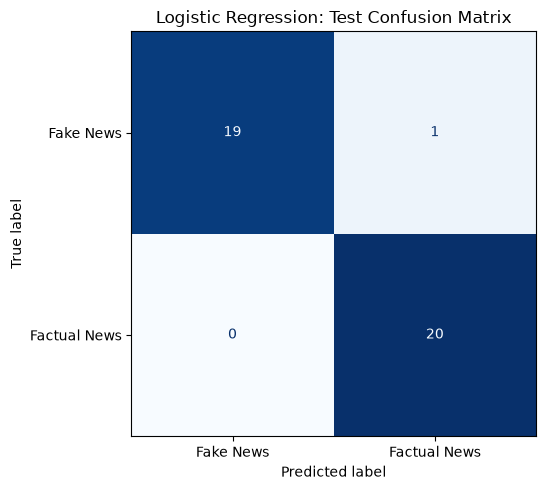

In [57]:
figure, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, labels=CLASS_LABELS, ax=axis,
    cmap="Blues", colorbar=False, values_format="d",
)
axis.set_title("Logistic Regression: Test Confusion Matrix")
figure.tight_layout()
plt.show()

## 30. 查看预测错误的新闻

保留原始索引与标题。若没有错误，则表格为空；这也不意味着模型在其他数据上不会出错。

In [58]:
test_results = classification_data.loc[X_test.index, ["title", LABEL_COLUMN]].copy()
test_results["Predicted"] = test_predictions
test_results["Correct"] = test_results[LABEL_COLUMN].eq(test_results["Predicted"])
misclassified_news = test_results.loc[~test_results["Correct"]]
print(f"分错新闻：{len(misclassified_news)} / {len(test_results)}")
display_full_table(misclassified_news)

分错新闻：1 / 40


,title,fake_or_factual,Predicted,Correct
150,RUSSIA’S STRANGE 45-ACRE MARYLAND COMPOUND Closed Down To Punish Diplomats,Fake News,Factual News,False


## 31. 自定义正文预测函数

输入一段完整英文新闻正文。返回类别及两类模型概率；概率是模型输出，未经校准，不能作为事实核查的可信度。模型输入仍是原始正文，Pipeline 自动完成转换。

In [59]:
def predict_news(text):
    """预测单篇非空正文，返回类别和按实际类别顺序对应的概率。"""
    if not isinstance(text, str) or not text.strip():
        raise ValueError("请输入非空的英文新闻正文")
    probabilities = news_classifier.predict_proba([text])[0]
    # 只转换一次 TF-IDF，最大概率对应最终类别。
    prediction = news_classifier.classes_[probabilities.argmax()]
    result = {"Predicted": prediction}
    # 不假设概率列顺序，使用分类器的 classes_ 对齐标签。
    result.update({f"P({label})": float(probability)
                   for label, probability in zip(news_classifier.classes_, probabilities)})
    return pd.DataFrame([result])

# 用一篇测试新闻演示；之后可将这一行参数替换成自己的英文正文。
predict_news(X_test.iloc[0])

,Predicted,P(Factual News),P(Fake News)
0,Factual News,0.607616,0.392384


## 32. 哪些词影响分类？

二分类逻辑回归的正系数倾向 `classes_[1]`，负系数倾向 `classes_[0]`。下面各展示权重最强的 15 个特征。系数不是因果解释；来源名称、署名和排版词也可能成为模型线索。

In [60]:
classifier_step = news_classifier.named_steps["logistic_regression"]
feature_weights = pd.DataFrame({
    "Feature": news_classifier.named_steps["tfidf"].get_feature_names_out(),
    "Coefficient": classifier_step.coef_[0],
}).sort_values("Coefficient")
print(f"负系数倾向：{classifier_step.classes_[0]}")
display(feature_weights.head(15))
print(f"正系数倾向：{classifier_step.classes_[1]}")
display(feature_weights.tail(15).sort_values("Coefficient", ascending=False))
assert set(X_train.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_test) == len(classification_data)
assert classifier_step.n_iter_.max() < classifier_step.max_iter
pd.testing.assert_frame_equal(news_data, news_data_snapshot)

负系数倾向：Factual News


,Feature,Coefficient
5955,reuters,-0.848876
6076,said,-0.730852
6095,said on,-0.562529
8297,washington reuters,-0.448934
4417,minister,-0.434582
5009,on wednesday,-0.376149
8354,wednesday,-0.362792
3809,its,-0.354221
5004,on tuesday,-0.353952
6102,said the,-0.346610


正系数倾向：Fake News


,Feature,Coefficient
7476,this,0.525839
8135,via,0.441176
8725,you,0.383208
3889,just,0.373183
1550,com,0.354995
5298,pic twitter,0.353297
7989,twitter com,0.353297
5297,pic,0.353297
3168,her,0.352769
5107,our,0.351678


## 33. 最终完整性检查

完成全部步骤后核对原始表和文件，分类器可通过 `predict_news(英文正文)` 调用。

In [61]:
pd.testing.assert_frame_equal(news_data, news_data_snapshot)
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_hash_before
print("全部分析完成，原始表与 CSV 未改变。")

全部分析完成，原始表与 CSV 未改变。
